# Домашнее задание 2

В этом задании вам предстоит реализовать контрастивное обучние эмбеддера, посмотреть на его влияние на задаче классификации и отбора кандидатов.

Языковое моделирование рассматривать не будем в силу дороговизны подхода.

## Часть 1. Triplet loss на стероидах

Вам поставили задачу: на фиксированном множестве точек произвести классификацию, при этом множество таково, что качество на исходных данных неприемлемо. Что делать? Последуем совету из лекции и реализуем контрастивное обучение.

В этом и последующем задании вам предстоит реализовать дообучение некоторого простого эмбеддера на домен.

Эмбеддинги заморожены -- будем дообучать только полносвязную голову.

In [ ]:
from dataclasses import dataclass

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np

In [ ]:
SEED = 42

@dataclass
class DatasetConfig:
    n_samples: int = 5000
    n_features: int = 32
    n_classes: int = 8
    n_clusters_per_class: int = 2
    n_informative: int = 5
    random_state: int = SEED

@dataclass
class SplitConfig:
    random_state: int = SEED
    test_size: float = 0.25

In [ ]:
X, y = make_classification(**DatasetConfig().__dict__)

X_train, X_test, y_train, y_test = train_test_split(X, y, **SplitConfig().__dict__)
X_train, y_train = torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float()

## 1.Визуализация данных - 1 баллов

Напишите функцию `plot_tsne(data, labels, **kwargs)`, принимающую на вход матрицу эмбеддингов и метки классификации и строящую t-SNE-разложение на плоскости. Изобразите его, раскрасив классы по цветам. Зафиксируйте `random_state` при построении.

Цель задания: получить визуальное представление о природе распределения в данных. Для доменной адаптации визуализация - важный инструмент интерпретации результата.

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Ваш код здесь ----
def plot_tsne(data, labels, plot_title):
    random_state = 42

    tsne = TSNE(n_components=2, random_state=42)
    data_2d = tsne.fit_transform(data)

    labels = np.array(labels)

    plt.figure(figsize=(10, 8))

    scatter = plt.scatter(
        data_2d[:, 0],
        data_2d[:, 1],
        c=labels,
        cmap='tab10',
        s=20
    )

    plt.colorbar(scatter)

    plt.title(plot_title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, alpha=0.3)

    plt.show()



## 2.Базовый классификатор

Выберем алгоритм классификации kNN и метрику качества Accuracy. Оценим базовое качество на тестовых данных.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


clf = KNeighborsClassifier(n_neighbors=10)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
score = accuracy_score(y_test, y_pred)

print(score)

0.5144


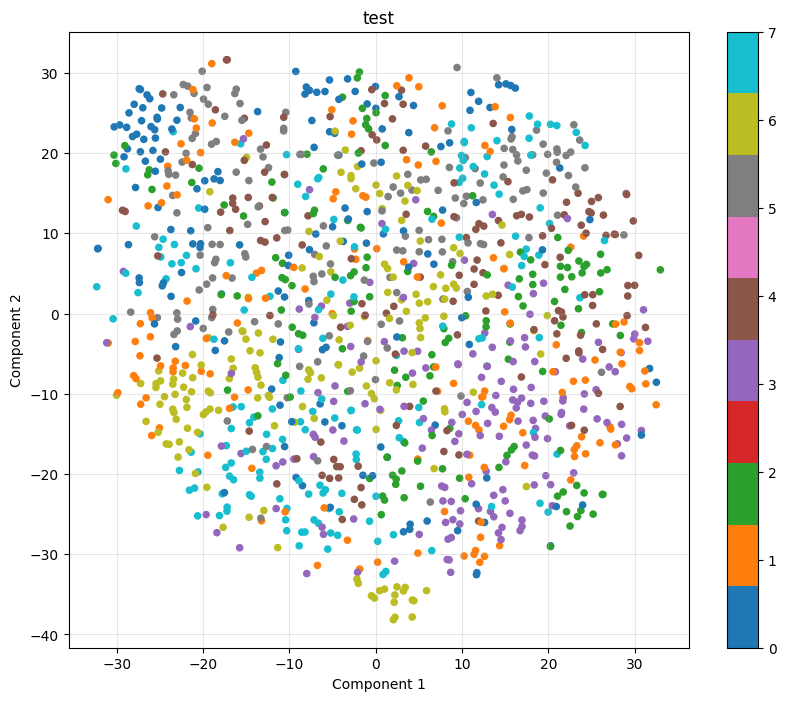

In [ ]:
plot_tsne(X_test, y_test, "test")

## 3.TripletLoss - 5 баллов

Давайте разберёмся, что такое Triplet Loss и как мы будем его использовать в несколько изменённом виде.

### Идея Triplet Loss

Цель обучения на Triplet Loss — научить модель отличать похожие объекты от непохожих. Для этого мы работаем с "триплетами" (тройками) векторов:

1.  **Якорь (`anchor`)**: Вектор нашего основного объекта $x$.
2.  **Позитив (`positive`)**: Вектор объекта $x^+$, который относится к тому же классу, что и якорь.
3.  **Негатив (`negative`)**: Вектор объекта $x^-$ из другого класса.

Цель — сделать так, чтобы в пространстве векторов "якорь" был ближе к "позитиву", чем к "негативу", причём с некоторым запасом (`margin`).

Функция ошибки Triplet Loss для одного триплета выглядит так:

$$\max\left(0,\|f(x)-f(x^+)\|^2_2-\|f(x)-f(x^-)\|^2_2+\varepsilon\right)$$

Заметим, что в случае L2-нормилизованных векторов:

$$\max\left(0,\|f(x)-f(x^+)\|^2_2-\|f(x)-f(x^-)\|^2_2+\varepsilon\right)=\max\left(0,f(x)f^T(x^-)-f(x)f^T(x^+)+\hat{\varepsilon}\right)$$

Пусть $D=\{x_i, y_i\}_i$ -- выборка классификации. Позитивные пары в $D$ формируются такими $(i,j)$, что $i \neq j$ и $y_i = y_j$, негативные - $i \neq j$ и $y_i \neq y_j$. Пусть $S=XX^T - \text{diag}(XX^T)$, где $\text{diag}(А)$ - преобразование квадратной матрицы $A$ к диагональной, в которой элементы на диагонали совпадают с диагональю $A$. То есть в $S$ диагональ занулена. По матрице $S$ можно сформировать два непересекающихся множества: позитивов $P$ и негативов $N$. Пусть $L$ -- минимальное количество элементов в каждом из двух множеств. Возьмем $\hat{P}=\{p_i\}_i$, $\hat{N}=\{n_i\}_i$ как сэмплы без возвращения размера $L$ из $P$ и $N$ соответственно. Тогда итоговая функция ошибки выглядит так:

$$\mathcal{L}=\frac{1}{L}\sum\limits_{i=1}^L\max\left(0, n_i-p_i+\hat{\varepsilon}\right)$$

В чем модификация? В том, что в паре позитивов и негативов не обязательно должен быть один и тот же якорный элемент. И это работает.

Реализуйте callable-класс `TripletLoss` по описанию.

Примечание: для прохождения тестов используйте сэмплирование через `np.random.default_rng(self.random_state).choice`.

In [ ]:
# ---- Ваш код здесь ----
class TripletLoss():

    def __init__(self, margin, random_state=None):
        self.margin = margin
        self.random_state = random_state

    def __call__(self, x, labels):
        # L2-нормализация
        x = x / torch.clamp(torch.norm(x, dim=1, keepdim=True), min=1e-12)

        s = x @ x.T
        s.fill_diagonal_(0.0)

        same_class = labels[:, None] == labels[None, :]
        diff_class = ~same_class

        same_class.fill_diagonal_(False)
        diff_class.fill_diagonal_(False)

        positives = s[same_class]
        negatives = s[diff_class]

        L = min(len(positives), len(negatives))

        pos_idx = np.random.default_rng(self.random_state).choice(
            len(positives), size=L, replace=False
        )
        neg_idx = np.random.default_rng(self.random_state).choice(
            len(negatives), size=L, replace=False
        )

        pos_idx = torch.as_tensor(pos_idx, device=x.device, dtype=torch.long)
        neg_idx = torch.as_tensor(neg_idx, device=x.device, dtype=torch.long)

        pos_sample = positives[pos_idx]
        neg_sample = negatives[neg_idx]

        loss = torch.clamp(neg_sample - pos_sample + self.margin, min=0.0).mean()
        return loss

In [ ]:
criterion = TripletLoss(0.2, random_state=101)


objects = torch.tensor(
    [[-1.7651, -1.5979,  0.1042,  0.3825, -0.9419, -0.2580, -0.6087, -0.1711,
        1.3922,  0.8548, -0.9251,  0.6989,  0.4238, -0.1330,  0.2985],
    [ 1.6144,  0.0627,  0.3424, -0.8591,  0.1869, -0.8598, -0.7200,  0.9449,
        -0.1684,  1.0282, -1.2377, -1.2640,  0.7469,  1.9605, -0.1214],
    [ 1.1143, -0.6948,  0.3739, -1.1461,  0.6456, -0.3360, -0.8111, -0.8861,
        0.7176, -0.6235, -0.9364,  0.6174,  2.7212, -2.0703, -2.2571],
    [ 0.7525,  2.1028,  2.7782,  0.5040, -1.5791,  1.5342,  0.0816,  0.3245,
        -0.0857, -0.5992, -1.4339,  0.0897, -1.5096,  0.1428, -0.1488],
    [-0.7518,  0.2623, -0.4958, -1.6063,  0.2537, -0.1137,  0.3985,  1.0155,
        0.1874, -0.4300, -1.2309,  1.5760, -1.3176,  1.5355,  1.8471],
    [ 1.9290, -0.3236,  0.4303,  0.7111,  1.4234,  1.7901,  0.2216, -1.5471,
        0.9389, -0.3012, -1.6487,  1.5765, -1.1450,  0.3260,  0.4909],
    [ 0.7837, -0.8004, -0.0929, -1.2220,  2.2333,  0.3288, -0.5222, -0.7202,
        0.6147,  1.8012, -0.2388, -0.2539,  0.0191, -0.0104,  0.5717],
    [-0.2709, -1.7985, -0.3959, -1.1190,  0.8644,  0.3008, -1.0336, -0.1251,
        -0.3357,  0.7938,  3.2090, -0.4332, -0.0496, -0.2672,  0.9690],
    [-0.1109,  0.4130,  0.7406, -1.2446, -0.4252,  2.5128, -0.2765,  0.6845,
        1.1965,  1.4173, -1.4604,  0.2515,  0.6387, -1.8519,  1.1899],
    [-0.1781, -0.7473, -0.1015,  0.2280, -1.5815,  0.1535, -1.3912, -2.2026,
        1.0496,  0.3547,  0.8897, -0.6482,  0.0133,  1.0124, -0.4452]])

labels = torch.LongTensor([1, 1, 2, 2, 3, 3, 4, 4, 5, 5])
assert abs(criterion(objects, labels).item() - 0.29527) < 1e-4

## 4.Модель и функция обучения - 8 балла

Реализуйте функцию `domain_adaptation(X_train, y_train, hidden_dim, out_dim, margin, N_epoch, batches_per_epoch, batch_size) -> MLP`, базовый цикл batch-обучения линейной головы, полносвязной нейронной сети. Батч для обучения можно либо сэмплировать произвольно из всего обучающего множества через `random.choice`, либо заранее сделать случайную перестановку датасета, как итог пройти `batches_per_epoch` батчей из датасета за одну эпоху.

Используйте реализацию полносвязной нейронной сети через класс `MLP`.

Требуется выбить на тесте 0.60 точности.

Цель задания - закрепить использование `TripletLoss` на простых модельных данных.

In [ ]:
import torch.optim as optim


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, out_dim, drop_prob=0.3):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.drop = nn.Dropout(drop_prob)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.drop(x)
        x = self.fc1(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x

In [ ]:
# ---- Ваш код здесь ----
def domain_adaptation(
        X_train, y_train,
        hidden_dim=128, out_dim=64, margin=0.2,
        N_epoch=40, batches_per_epoch=750, batch_size=72):

    X_train = torch.as_tensor(X_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.long)

    input_dim = X_train.shape[1]

    model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, out_dim=out_dim, drop_prob=0.1)
    criterion = TripletLoss(margin=margin, random_state=42)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    n_samples = X_train.shape[0]

    model.train()
    for _ in range(N_epoch):
        for _ in range(batches_per_epoch):
            batch_indices = np.random.choice(n_samples, size=batch_size, replace=False)
            batch_indices = torch.as_tensor(batch_indices, dtype=torch.long)

            x_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]

            optimizer.zero_grad()
            out = model(x_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()

    return model



In [ ]:
trained_model = domain_adaptation(X_train, y_train, N_epoch = 120, margin=0.1, batch_size=64, batches_per_epoch = 128)

## 5.Итоговое качество - 1 балл

Отобразите новое распределение t-SNE-координат и посчитайте тестовую метрику. Сделайте краткий вывод.

Что тут важно: перед тем, как применить kNN-классификатор, который несколько строчек кода назад был нашим baseline-решением, нужно применить над исходными данными преобразование обученной моделью представлений, фактически выходом функции `domain_adaptation`.

Цель задания: изучить, как поменялось распределение в данных после доменной адаптации.

Визуализируем успех


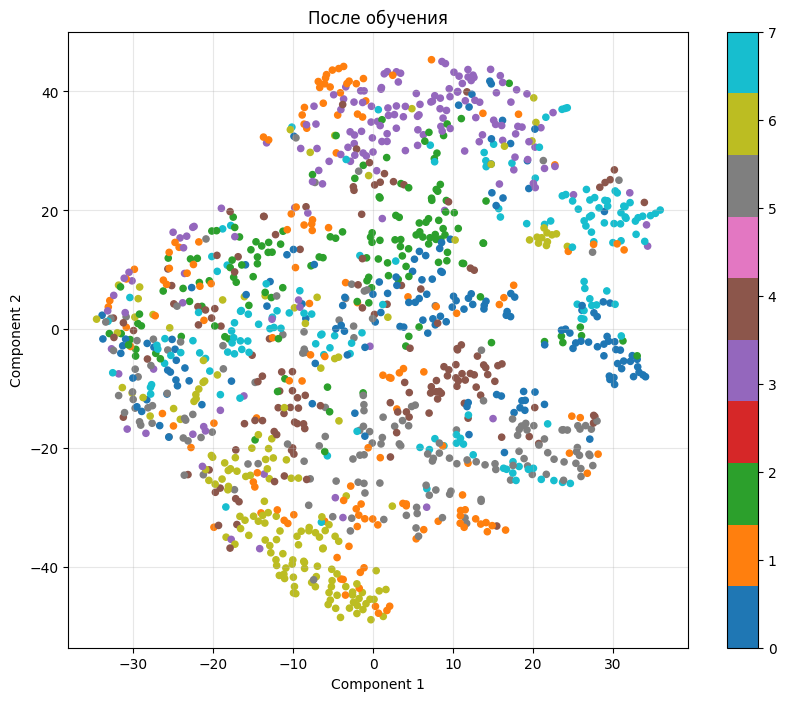

In [ ]:
# ---- Ваш код здесь ----
print("Визуализируем успех")

X_test, y_test = torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long()

trained_model.eval()

# переводим train embeddings
with torch.no_grad():
    X_test_emb = trained_model(X_test)
    X_train_emb = trained_model(X_train)

X_test_emb = X_test_emb.cpu().numpy()
X_train_emb = X_train_emb.cpu().numpy()


plot_tsne(X_test_emb, y_test, "После обучения")


In [ ]:
# ---- Ваш код здесь ----
print("Считаем точность на тесте")

# обучаем kNN
clf = KNeighborsClassifier(n_neighbors=10)
clf.fit(X_train_emb, y_train)

y_pred = clf.predict(X_test_emb)
score = accuracy_score(y_test, y_pred)

print(score)


# ---- Конец кода ----


Считаем точность на тесте
0.6216


## Часть 2. Triplet loss на чем-то посерьезнее

Рассмотрим теперь более живую задачу классификации. Будем работать с новостными группами.

Постановка та же, только возьмем теперь предобученный эмбеддер с HF. Эмбеддинги заморожены -- будем дообучать только полносвязную голову.

Поменяем так же алгоритм классификации с kNN на LogReg (по большей части для разнообразия).

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
categories = [
    "sci.space",
    "sci.med",
    "sci.electronics",
    "comp.os.ms-windows.misc",
    "comp.sys.ibm.pc.hardware",
    "comp.sys.mac.hardware"
]

newsgroups_train = fetch_20newsgroups(subset="train", categories=categories)
newsgroups_test = fetch_20newsgroups(subset="test", categories=categories)

X_train = newsgroups_train.data
X_test = newsgroups_test.data

y_train = newsgroups_train.target
y_test = newsgroups_test.target

In [ ]:
def test_logreg(X_train_mapped, y_train, X_test_mapped, y_test, target_names=newsgroups_test.target_names):
    clf = LogisticRegression(max_iter=10000)
    clf.fit(X_train_mapped, y_train)

    y_pred = clf.predict(X_test_mapped)
    score = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names)

    print(f"Accuracy: {score:.3f}")
    print(f"Classification Report: {report}")

## 1.Выбираем англоязычный эмбеддер и формируем эмбеддинги - 1 балл

Выберите небольшой англоязычный sentence-трансформер, обученный на семантику, и прогоните через нее тексты обучения и тестирования.

Замерьте базовое качество классификатора на этих эмбеддингах.

Опционально: крайне рекомендую прогнать `plot_tsne` из прошлой части на тесте в тех же целях, что и в прошлых заданиях.

Цель задания: применить навыки выбора модели на основе описания ее области применения.

In [ ]:
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# ---- Ваш код здесь ----
print("Определяем модель, получаем эмбеддинги, визуализируем тест через t-SNE")

model_name="sentence-transformers/all-MiniLM-L6-v2"

encoder = SentenceTransformer(model_name)
batch_size = 64
normalize_embeddings = True

X_train_emb = encoder.encode(X_train,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=normalize_embeddings)

X_test_emb = encoder.encode(X_test,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=normalize_embeddings)

test_logreg(X_train_emb, y_train, X_test_emb, y_test)

# ---- Конец кода ----


Определяем модель, получаем эмбеддинги, визуализируем тест через t-SNE


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Accuracy: 0.827
Classification Report:                           precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.82      0.84      0.83       394
comp.sys.ibm.pc.hardware       0.74      0.69      0.72       392
   comp.sys.mac.hardware       0.78      0.78      0.78       385
         sci.electronics       0.76      0.76      0.76       393
                 sci.med       0.94      0.95      0.94       396
               sci.space       0.92      0.93      0.93       394

                accuracy                           0.83      2354
               macro avg       0.83      0.83      0.83      2354
            weighted avg       0.83      0.83      0.83      2354



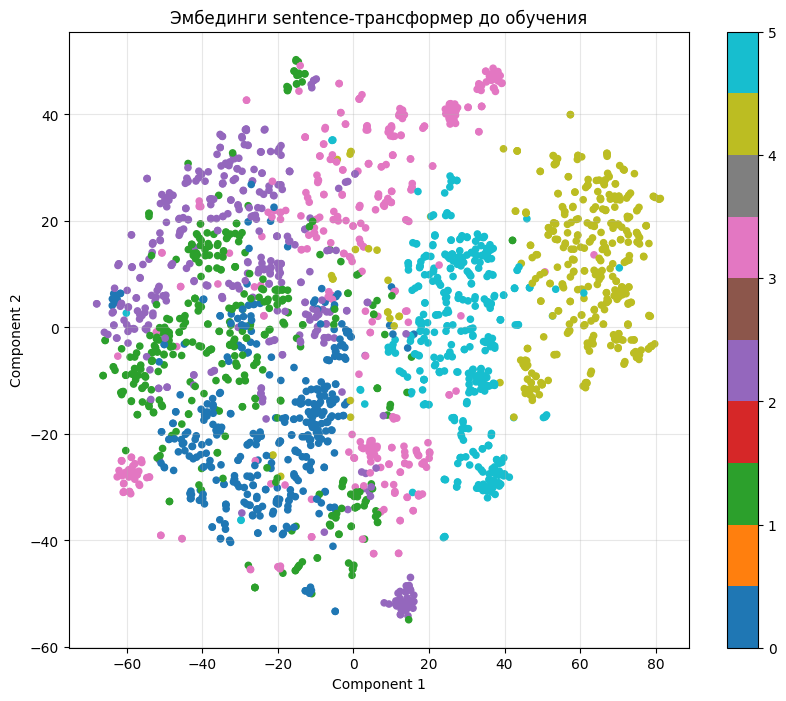

In [ ]:
plot_tsne(X_test_emb, y_test, "Эмбединги sentence-трансформер до обучения")

## 2.Обучаем эмбеддинги под задачу - 1 балл

Теперь точно придется обратиться к Части 1. Необходимо взять `domain adaptation` и обучить эмбеддиги на домен. Выходом будет линейная голова, как и в прошлой части, которую мы применим как преобразование исходных данных для улучшения представления и более качественного решения конечной задачи, в данном случае классификации.

In [ ]:
# ---- Ваш код здесь ----
print("Доменно адаптируемся")


# X_test_emb_orig, y_test = torch.from_numpy(X_test_emb).float(), torch.from_numpy(y_test).long()
# X_train_emb_orig, y_train = torch.from_numpy(X_train_emb).float(), torch.from_numpy(y_train).long()

trained_model = domain_adaptation(X_train_emb_orig, y_train, N_epoch = 60, margin=0.4, batch_size=64, batches_per_epoch = 55)

trained_model.eval()

with torch.no_grad():
    X_train_emb_trained = trained_model(X_train_emb_orig)
    X_test_emb_trained = trained_model(X_test_emb_orig)

# ---- Конец кода ----


Доменно адаптируемся


## 3.Замеряем качество - 1 балл

Обучитите базовый классификатор на новом пространстве эмбеддингов, сравните результаты с baseline-решением, полученным через функцию `test_logreg` выше, обязательно сделайте вывод.

На всякий случай, в этом задании вам тоже нужно вызвать `test_logreg`, только с другими аргументами (новым преобразованием данных).

Опционально: вновь крайне рекомендую прогнать `plot_tsne` из прошлой части на тесте, только уже в новом пространстве.

Примечание: в референсном решении качество растет с $0.821$ до $0.879$.

In [ ]:
# ---- Ваш код здесь ----
print("Радуемся росту качества")
test_logreg(X_train_emb_trained, y_train, X_test_emb_trained, y_test)

# ---- Конец кода ----


Радуемся росту качества
Accuracy: 0.855
Classification Report:                           precision    recall  f1-score   support

 comp.os.ms-windows.misc       0.86      0.82      0.84       394
comp.sys.ibm.pc.hardware       0.73      0.80      0.76       392
   comp.sys.mac.hardware       0.80      0.82      0.81       385
         sci.electronics       0.82      0.80      0.81       393
                 sci.med       0.97      0.94      0.96       396
               sci.space       0.95      0.94      0.95       394

                accuracy                           0.85      2354
               macro avg       0.86      0.85      0.86      2354
            weighted avg       0.86      0.85      0.86      2354



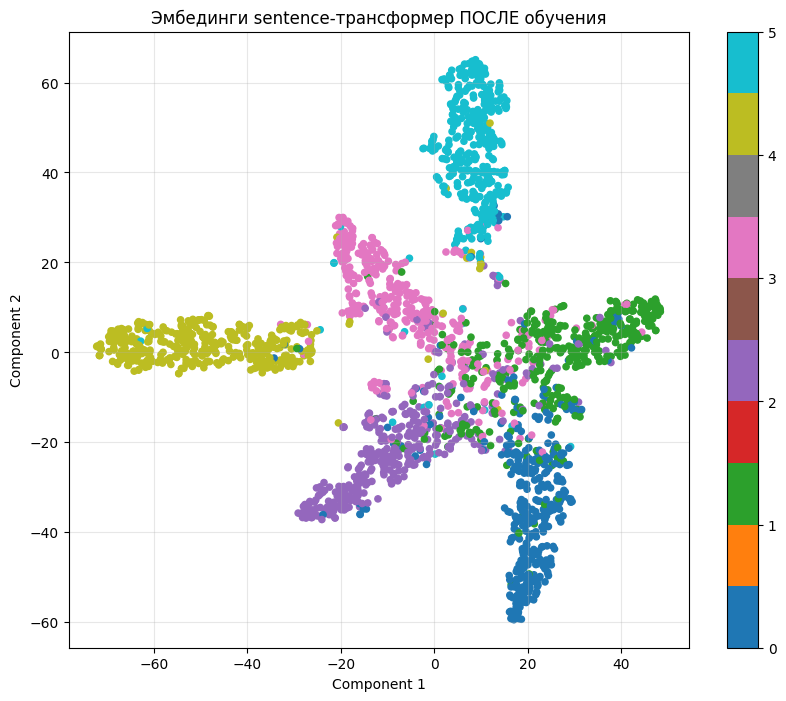

In [ ]:
plot_tsne(X_test_emb_trained, y_test, "Эмбединги sentence-трансформер ПОСЛЕ обучения")

# Часть 3. Контрастивное обучение для поискового отбора кандидатов.

Эта часть будет более кейс-ориентированной, мы разберем сценарий, в котором контрастивное обучение является стандартной практикой улучшения качества модели на конечной задаче.

Бизнес-кейс:
> Требуется улучшить этап отбора кандидатов в поисковой веб-системе. На текущий момент в качестве кандгена (кандидатогенерации) используется BM25 и обратный индекс. BM25 уже тюнили, дальше качество нарастить не выходит. В качестве бизнес-метрики можем взять производные поведенческого отклика, например, CTR@K или timespent на выдаче и документах.

Очевидным направлением развития является построение нейросетевого кандгена. Обычно в описанных случаях действуют следующим образом:

0. Выбирают ML-метрику, которую хотелось бы оптимизировать. Для кандгена катастрофически важно выдать как можно больше релеватных документов в пределах фиксированной длины выдачи, поэтому подходящая метрика -- Recall@K. Мы будем использовать ее модификацию, но об этом позже.
1. Сэмплируют запросы из потока / формируют специфичные корзины запросов в зависимости от дополнительных бизнес-требований. Давайте считать, что они отсутствуют. Тут обязателен контроль их качества, можно исходить из символьных эвристик или применять LLM для классификации, как вы это делали в предыдущей домашке.
2. Обкачивают поисковый движок, формируя глубокие выдачи. Эпитет "глубокие" относится к глубине погружения пользователя в выдачу, то есть предельные позиции взаимодействия с документами. Так вот для обучения требуется брать документов в избытке, в том числе те, с которыми пользователь никогда бы не повзаимодействовал. В целом, длина выдачи 1000 -- отличный выбор. В качестве ремарки, обычно в данном случае прибегают к выкручиванию параметров отбора по BM25 для гарантированно длинной выдачи.
3. Разметка пар запрос-документ на задачу релевантности. LLM -- вновь отличный выбор. Разметка порядковая, но может быть как бинарной, так и n-арной. Релевантность - относительное понятие, отсюда следует, что множество возможных значений релевантности является упорядоченным. Важно сформировать определение "релевантного" документа, то есть определить порог, по которому мы будем считать документ подходящим под запрос. Порогом в данном случае является некоторое значение из множества всевозможных значений релевантности, которое является минимальным для определения позитивности пары запрос-документ.
4. Релевантные пары запрос-документ берем в качестве позитивов, выбираем базовый эмбеддер и учим его контрастивно как bi-энкодер на эту выборку, негативы можем формировать в режиме in-batch.
5. Если все сделано верно (данных достаточно, гиперпараметры подобраны, код не багованный), естественным следствием будет рост качества, поздравляю.

Датасет, на котором мы будем строить кандген -- MS Marco Dev. В качестве эмбеддера вы вольны использовать любые модели, которые не учились на MS Marco, например, `"microsoft/deberta-v3-small"`.

Мы привыкли в основном, что датасеты собраны на HF, но в этот раз рассмотрим другую библиотеку для работы с датасетами, `ir_datasets` ([API](https://ir-datasets.com/python.html)). "IR" от Information Retrieval - библиотека содержит инструменты работы с датасетами поиска. Также в коде будет использоваться `polars` ([API](https://docs.pola.rs/api/python/stable/reference/index.html)), аналог всеми известной `pandas`, только на порядки быстрее.

Описание датасета читайте [тут](https://ir-datasets.com/msmarco-passage.html#msmarco-passage/dev/judged).

In [1]:
# !pip install ir_datasets
# !pip install faiss-cpu

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.7 MB/s eta 0:00:00
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=03bd384aedc83e3b901e80762999b8f20b82dca8999fc977a5065adc774f248a
  Stored in directory: /root/.cache/pip/wheels/f6/85/c2/9f0f621def52a1d5db7d29984f81e45f9fb6dfeb1a4eb6e31c
  Created wheel for cbor: filename=cbor-1.0.0-cp312-cp312-linux_x86_64.whl size=55022 sha256=549b02e4c86de9ed9ca1caf001e5dedf00e4697a13f6ec9c00069d83f7872531
  Stored in directory: /root/.cache/pip/wheels/44/3e/21/a739cbcc331a1ab45c326d6edbdac6118de4402f6076e30ff1
Successfully built warc3-wet-clueweb09 cbor
   ━━━━━━

In [2]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from transformers import AutoModel, AutoTokenizer

import re
from dataclasses import dataclass
from collections import defaultdict
from functools import partial
from tqdm import tqdm

import numpy as np
import ir_datasets
import polars as pl

import faiss
from sklearn.model_selection import train_test_split

In [3]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
@dataclass
class Columns:
    query_id: str = "query_id"
    doc_id: str = "doc_id"
    index_id: str = "index_id"
    text: str = "text"
    qrels_relevance: str = "relevance"


@dataclass
class DatasetConfig:
    sampled_index_size: int = 150_000
    relevance_threshold: int = 1
    test_size: float = 0.2

In [5]:
dataset = ir_datasets.load("msmarco-passage/dev/judged")

columns = Columns()
dataset_config = DatasetConfig()

In [6]:
queries = pl.DataFrame(dataset.queries_iter()).select(
    pl.col(columns.query_id).cast(pl.Int32),
    pl.col(columns.text)
)

qrels = pl.DataFrame(dataset.qrels_iter()).drop("iteration").select(
    pl.col(columns.query_id).cast(pl.Int32),
    pl.col(columns.doc_id).cast(pl.Int32),
    pl.col(columns.qrels_relevance).cast(pl.Int32)
)

documents = pl.DataFrame(dataset.docs_iter()).select(
    pl.col(columns.doc_id).cast(pl.Int32),
    pl.col(columns.text)
)

[INFO] Please confirm you agree to the MSMARCO data usage agreement found at <http://www.msmarco.org/dataset.aspx>
[INFO] [starting] https://msmarco.z22.web.core.windows.net/msmarcoranking/qrels.dev.tsv
[INFO] [finished] https://msmarco.z22.web.core.windows.net/msmarcoranking/qrels.dev.tsv: [00:00] [1.20MB] [1.75MB/s]
[INFO] If you have a local copy of https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/c177b2795d5f2dcc524cf00fcd973be1
[INFO] [starting] https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz
[INFO] [finished] https://msmarco.z22.web.core.windows.net/msmarcoranking/queries.tar.gz: [00:01] [18.9MB] [11.1MB/s]
[INFO] If you have a local copy of https://msmarco.z22.web.core.windows.net/msmarcoranking/collectionandqueries.tar.gz, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/31644046b18952c1386cd4564ba2ae69
[INFO] [star

In [7]:
target_document_ids = qrels[columns.doc_id].unique().to_list()
sampled_document_ids = np.random.default_rng().integers(dataset.docs_count(), size=dataset_config.sampled_index_size).tolist()

sampled_documents = documents.filter(pl.col(columns.doc_id).is_in(sampled_document_ids + target_document_ids)).with_row_index(columns.index_id)
len(target_document_ids), len(sampled_document_ids)

(59096, 150000)

In [8]:
train_qrels, test_qrels = train_test_split(qrels, test_size=dataset_config.test_size)

train_queries = queries.filter(pl.col(columns.query_id).is_in(train_qrels[columns.query_id].implode()))
test_queries = queries.filter(pl.col(columns.query_id).is_in(test_qrels[columns.query_id].implode()))

train_documents = sampled_documents.filter(pl.col(columns.doc_id).is_in(train_qrels[columns.doc_id].implode()))
test_documents = sampled_documents.filter(pl.col(columns.doc_id).is_in(test_qrels[columns.doc_id].implode()))


## 0.Дополните параметры конфигов в зависимости от вашей реализации модели и обучения

Задайте параметры токенизации, обучения, значения параметров функции ошибки и дополнительные параметры модели.
Что стоит добавить в конфиг модели:
- возможность заморозить хвост и дообучать только голову (делается через регулярки и `model.named_parameters()`)
- снижение размерности за счет дополнительной полносвязной сети
- параметры для этой дополнительной сети

Описание полей конфига функции ошибки читай ниже.

In [9]:
@dataclass
class TrainTestConfig:
    device: str = torch.device(["cpu", "cuda"][torch.cuda.is_available()])
# ---- Ваш код здесь ----
# ---- Конец кода ----

@dataclass
class ModelConfig:
    model_name: str = "microsoft/deberta-v3-small"
# ---- Ваш код здесь ----
    # tokenization
    query_max_length: int = 32
    doc_max_length: int = 128

    # freeze setup
    train_head_only: bool = True

    # projection head
    use_projection_head: bool = True
    projection_hidden_dim: int = 256
    projection_out_dim: int = 128
    projection_dropout: float = 0.1

    # pooling
    pooling: str = "mean"
    normalize_embeddings: bool = True

# ---- Конец кода ----

@dataclass
class LossConfig:
# ---- Ваш код здесь ----
    thrsh: float = 0.3
    temperature: float = 0.05
# ---- Конец кода ----


In [10]:
columns = Columns()
dataset_config = DatasetConfig()
train_test_config = TrainTestConfig()

# ---- Ваш код здесь ----
model_config = ModelConfig()
# ---- Конец кода ----



## 1.Датасет - 4 баллов

Напишите класс `DenseRetrievalDataset`, наследованный от `Dataset`, который внутри формирует множество релевантных пар и выдает на каждый индекс произвольную пару оттуда вместе с `query_id` и `doc_id`. Эта функциональность должна быть инкапсулирована в методе `_build_positive_pairs`. Обратите внимание на `relevance_threshold` из конфига датасета, используйте ее для формирования позитивных пар.

Напишите также функцию `train_collate_fn` для DataLoader'а, которая внутри токенизирует батчем текст запроса и документа и отдает кортеж из тензоров, в которые включаются id запросов и документов, токены запросов и документов.

In [11]:
class DenseRetrievalDataset(Dataset):
    def __init__(self, queries, documents, qrels, columns, config):
        self.columns = columns
        self.config = config

        self.queries = queries
        self.documents = documents
        self.qrels = self._build_positive_pairs(qrels)

    def _build_positive_pairs(self, qrels):
        threshold = self.config["relevance_threshold"]
        positive_pairs = []

        for _, row in qrels.iterrows():
            if row[self.columns["relevance"]] >= threshold:
                positive_pairs.append(
                    (
                        row[self.columns["query_id"]],
                        row[self.columns["doc_id"]],
                    )
                )
        return positive_pairs

    def __len__(self):
        return len(self.qrels)

    def __getitem__(self, idx):
        query_id, doc_id = self.qrels[idx]

        return {
            "query": self.queries[query_id],
            "document": self.documents[doc_id],
            "query_id": query_id,
            "doc_id": doc_id,
        }

# ---- Конец кода ----


In [12]:
def train_collate_fn(data, tokenizer, config):

    queries = [item["query"] for item in data]
    documents = [item["document"] for item in data]
    query_ids = [item["query_id"] for item in data]
    doc_ids = [item["doc_id"] for item in data]

    query_tokens = tokenizer(
        queries,
        padding=True,
        truncation=True,
        max_length=config.query_max_length,
        return_tensors="pt"
    )

    doc_tokens = tokenizer(
        documents,
        padding=True,
        truncation=True,
        max_length=config.doc_max_length,
        return_tensors="pt"
    )

    query_ids = torch.tensor(query_ids, dtype=torch.long)
    doc_ids = torch.tensor(doc_ids, dtype=torch.long)

    return query_ids, doc_ids, query_tokens, doc_tokens

## 2.Функция ошибки - 5 баллов

Реализуйте класс `ContrastiveLoss`, который реализует расчет следующей функции ошибки:
$$\mathcal{L}=\mathbb{E}_C\text{CrossEntropy}\left(\frac{q_iD^T}{\tau}-B_i, M_i\right)$$
$$C=\{Q, D\},\quad Q=\{q_i\big|q_i\in\mathbb{R}^n,\|q_i\|_2=1\}_{i=1}^N,\quad D=\{d_i\big|d_i\in\mathbb{R}^n,\|d_i\|_2=1\}_{i=1}^N$$
$$(q_i, d_i) \,-\,\text{позитивная пара}$$

Здесь $C$ - батч запросов-документов, где на соответствующих индексах $i$ стоят заведомо позитивные пары, $\tau$ - температура, регулирующая "агрессивность" сближения позитивных пар.

В качестве таргетов в кросс-энтропии используются $M_i$. Перед тем, как выписать его формулу, введем обозначение $\text{QID}_i$ как id запроса, эмбеддинг которого - $q_i$, в коде это `query_id` в датасете запросов. $M_i$ вычисляется следующим образом:

$$M_i\in[0,1]^N,\quad \forall{j}\in\overline{1,N}:\;M[j]=\frac{[\text{QID}_i = \text{QID}_j]}{\sum\limits_k{[\text{QID}_i = \text{QID}_k]}}$$

Фактически это вероятностный вектор, где ненулевые элементы соответствуют позитивным парам. Для того, чтобы избежать необходимости дедублицировать батч по запросам (по $\text{QID}$), формула подразумевает равномерное "размазывание" вероятности по одинаковым запросам из батча.

Внутри формулы добавлен параметр $B_i$, который формулируется следующим образом:
$$B_i\in[0,1]^N,\quad \forall{j}\in\overline{1,N}:\;M[j]=b*[q_i = q_j]$$
$$b\,-\,\text{вещественный гиперпараметр}$$

Смысл $b$ смотрите в [статье LaBSE](https://arxiv.org/pdf/2007.01852), _Additive Margin Softmax_. Если нет времени разбираться, задайте $b$ равным $0$.

Фактически вы напишите `InfoNCE` с in-batch-негативами.

Подсказка: не упаковывайте расчет $M_i$ внутрь функции ошибки, сделайте ее внешней. Она вам пригодится в функции обучения.

In [13]:
# ---- Ваш код здесь ----
class ContrastiveLoss(nn.Module):
    def __init__(self, thrsh, temperature):
        super().__init__()
        self.thrsh = thrsh
        self.temperature = temperature

    def forward(self, queries, documents, labels):

        q_emb = F.normalize(queries, p=2, dim=1)
        d_emb = F.normalize(documents, p=2, dim=1)

        logits = q_emb @ d_emb.T
        logits = logits / self.temperature

        if self.thrsh > 0:
            same_ids = (labels > 0).float()
            logits = logits - self.thrsh * same_ids

        log_probs = F.log_softmax(logits, dim=1)
        loss = -(labels * log_probs).sum(dim=1).mean()

        return loss


# ---- Конец кода ----

def build_label_mask(entity_ids):
    mask = (entity_ids.view(-1, 1) == entity_ids.view(1, -1)).type_as(entity_ids)
    mask = mask / mask.sum(dim=-1, keepdim=True)
    return mask

In [14]:
criterion = ContrastiveLoss(0.1, 0.05)


queries = torch.tensor(
    [[ 0.5803,  0.9579, -1.7393,  0.8502,  1.0579,  1.1222, -1.3303,  2.1554,
        -0.2404,  1.7580,  0.1433,  0.6232, -0.9371,  0.7069,  0.9060],
    [ 1.4968, -0.4212, -0.3566, -0.1982,  0.3722,  0.4442,  1.0164,  0.8380,
        -0.5248, -1.1686,  1.3973, -0.6910, -0.5832, -0.2636, -1.0497],
    [ 0.1836, -1.2159, -0.5191, -1.5825,  0.4003, -0.6419, -1.1341,  0.2970,
        -1.1792,  2.1851,  2.3077,  0.3735,  1.4981,  0.6243,  1.2269],
    [-2.7559, -0.2543,  0.6742, -0.0188, -0.3204,  0.2138,  0.2517, -2.2059,
        -1.3797, -1.5980, -1.3527,  1.5497, -0.7449,  0.6207, -1.8088],
    [ 0.7241,  1.2993,  0.8433,  0.1442, -1.0798,  1.7103,  0.0768, -1.0067,
        -0.4282,  0.7578, -0.0629, -0.4202,  0.8126, -0.1174,  0.8947],
    [ 1.7049, -0.6559,  0.4521, -0.4866,  0.2823, -0.0065, -0.6142,  0.9237,
        -0.6907,  0.6034,  0.2700,  1.0026,  0.9323,  1.3452, -1.1236]])

documents = torch.tensor(
    [[ 0.8498,  1.4255, -1.3913, -0.0906,  2.6704, -1.5063, -1.5604, -0.4563,
        0.4762,  0.7897, -0.1102,  0.1176,  0.3902,  1.5095, -0.3534],
    [-0.9154, -0.1968,  0.5091,  0.0156, -1.6841, -1.1580,  1.2767,  2.6576,
        -0.3602,  0.4782,  0.7819,  0.7402, -0.8883, -0.1158,  1.0545],
    [-0.8661,  0.3513, -1.8400, -3.5891, -1.3286, -0.1409, -1.3466,  1.1086,
        0.4160,  2.5859,  0.0813, -0.5245,  0.1244,  0.3139,  1.2755],
    [ 0.1836, -1.2159, -0.5191, -1.5825,  0.4003, -0.6419, -1.1341,  0.2970,
        -1.1792,  2.1851,  2.3077,  0.3735,  1.4981,  0.6243,  1.2269],
    [-1.2163,  0.2481, -1.9740,  0.2509,  1.0521,  0.5903, -0.6070, -0.6650,
        -0.1618,  0.5526,  0.6654,  0.9530, -0.5084,  1.8372, -0.2625],
    [ 1.4968, -0.4212, -0.3566, -0.1982,  0.3722,  0.4442,  1.0164,  0.8380,
        -0.5248, -1.1686,  1.3973, -0.6910, -0.5832, -0.2636, -1.0497]])

labels = torch.eye(queries.size(0))
assert abs(criterion(queries, documents, labels).item() - 8.74177) < 1e-3

labels = torch.tensor(
    [[0.5000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000],
    [0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.3333],
    [0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000],
    [0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.3333],
    [0.5000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000],
    [0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.3333]])
assert abs(criterion(queries, documents, labels).item() - 7.47976) < 1e-3

## 3.Модель - 4 баллов

Реализуйте класс `Embedder`, который возвращает матрицу эмбеддингов по выходу токенизатора. Вы вольны выбирать архитектуру, но суть работы модели должна сохраняться.

In [15]:
class Embedder(nn.Module):
    def __init__(self, config):
        super().__init__()
# ---- Ваш код здесь ----
        self.config = config
        self.model = AutoModel.from_pretrained(config.model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(config.model_name)

        hidden_size = self.model.config.hidden_size

        if config.use_projection_head:
            self.projection = nn.Sequential(
                nn.Linear(hidden_size, config.projection_hidden_dim),
                nn.GELU(),
                nn.Dropout(config.projection_dropout),
                nn.Linear(config.projection_hidden_dim, config.projection_out_dim),
            )
            self.output_dim = config.projection_out_dim
        else:
            self.projection = nn.Identity()
            self.output_dim = hidden_size

        if config.train_head_only:
            for param in self.model.parameters():
                param.requires_grad = False

    def forward(self, batch):

        outputs = self.model(**batch)
        token_embeddings = outputs.last_hidden_state

        mask = batch["attention_mask"].unsqueeze(-1).float()
        summed = (token_embeddings * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        emb = summed / counts

        emb = self.projection(emb)

        if self.config.normalize_embeddings:
            emb = F.normalize(emb, p=2, dim=1)

        return emb


# ---- Конец кода ----


## 4.Тестовая метрика и инференс - 5 баллов

Напишите функцию `calc_recall(index, query_embeddings, query_ids, qrels, documents, columns, config)`, которая по тестовой выборке эмбеддингов запросов `query_embeddings`, описываемые id запросов `query_ids`, извлекает наиболее релевантные документы из индекса документов `index` (стройте по `sampled_documents`) и по парам позитивов `qrels` и отображению id индекса в id документов `documents` (см. класс `Columns` и определение датасета) расчитывает средний модифицированный `Recall@K` по всем запросам. `@K` берите несколько, задайте списком через `config`.

$$Recall@K=\frac{\#[\text{число релевантных запросу документов в top-K}]}{\min\left(\#[\text{число всех релевантных запросу документов}],\, \#[\text{документов в выдаче по запросу}]\right)}$$

Для построения индекса документов используйте `faiss`.

Напишите функцию `inference(embedder, texts, is_query, config)`, которая прогоняет эмбеддер по текстам, `is_query` -- флаг того, являются ли тексты запросами или нет (для задания `max_length` в токенизации).

Напишите функцию `test_retriever(embedder, test_queries, test_qrels, documents, columns, config)`, которая считает тестовую метрику (запускает `calc_recall`).

In [16]:
# def calc_recall(index, query_embeddings, query_ids, qrels, documents, columns, config):
#     k_values = config.k_values  # например [1, 5, 10]

#     recalls = {k: [] for k in k_values}

#     # поиск ближайших
#     max_k = max(k_values)
#     scores, indices = index.search(query_embeddings, max_k)

#     # маппинг doc index → doc_id
#     doc_ids = documents[columns.doc_id].values

#     for i, qid in enumerate(query_ids):
#         retrieved_doc_ids = doc_ids[indices[i]]

#         # релевантные документы для этого запроса
#         relevant = qrels[
#             qrels[columns.query_id] == qid
#         ][columns.doc_id].values

#         relevant_set = set(relevant)

#         for k in k_values:
#             top_k = retrieved_doc_ids[:k]

#             hits = sum(doc in relevant_set for doc in top_k)

#             denom = min(len(relevant_set), k)
#             recall = hits / denom if denom > 0 else 0.0

#             recalls[k].append(recall)

#     # усреднение
#     return {k: np.mean(recalls[k]) for k in k_values}


In [17]:
# def inference(embedder, texts, is_query, config):
#     embedder.eval()

#     # max_length = (
#     #     config.query_max_length if is_query else config.doc_max_length
#     # )
#     max_length = 64
#     batch_size = 32

#     embeddings = []

#     with torch.no_grad():
#         for i in range(0, len(texts), batch_size):
#             batch_texts = texts[i:i + batch_size]

#             batch = embedder.tokenizer(
#                 batch_texts,
#                 padding=True,
#                 truncation=True,
#                 max_length=max_length,
#                 return_tensors="pt"
#             ) #.to(config.device)

#             emb = embedder(batch)  # (B, dim)
#             embeddings.append(emb.cpu().numpy())

#     return np.vstack(embeddings)

In [18]:
# def test_retriever(embedder, test_queries, test_qrels, documents, columns, config):
#     # тексты
#     query_texts = test_queries[columns.text].to_list()
#     query_ids = test_queries[columns.query_id].to_numpy()

#     doc_texts = documents[columns.text].to_list()

#     # эмбеддинги
#     query_embeddings = inference(embedder, query_texts, True, config)
#     doc_embeddings = inference(embedder, doc_texts, False, config)

#     # FAISS index
#     dim = doc_embeddings.shape[1]
#     index = faiss.IndexFlatIP(dim)  # cosine через нормализацию
#     index.add(doc_embeddings)

#     # считаем recall
#     recall = calc_recall(
#         index,
#         query_embeddings,
#         query_ids,
#         test_qrels,
#         documents,
#         columns,
#         config,
#     )

#     print(f"Recall: {recall}")

## 5.Функция обучения - 10 баллов

Напишите функцию `train_retriever(embedder, train_queries, train_documents, train_qrels, test_queries, test_qrels, documents, columns, dataset_config, train_test_config, loss_config)`, которая готовит все loader'ы, обучает модель в контрастивном режиме и считает раз в эпоху тестовую метрику.

Поэкспериментируйте с функцией ошибки, сделайте линейную комбинацию из `loss(q, d)` и `loss(d, q)` для обучения. Посмотрите на влияние такой смены ролей запроса и документа на итоговые метрики.

Стоит использовать `gradient accumulation`, который несложно пишется руками.

In [19]:
from tqdm.auto import tqdm


In [20]:
# def train_retriever(
#         embedder,
#         train_queries, train_documents, train_qrels,
#         test_queries, test_qrels,
#         documents, columns,
#         dataset_config, train_test_config, loss_config
#     ):
# # ---- Ваш код здесь ----
#     train_dataset = DenseRetrievalDataset(
#         queries=train_queries,
#         documents=train_documents,
#         qrels=train_qrels,
#         columns=columns,
#         config=dataset_config,
#     )

#     train_loader = DataLoader(
#         train_dataset,
#         batch_size=train_test_config.batch_size,
#         shuffle=True,
#         collate_fn=lambda batch: train_collate_fn(
#             batch,
#             tokenizer=embedder.tokenizer,
#             query_max_length=embedder.config.query_max_length,
#             doc_max_length=embedder.config.doc_max_length,
#         ),
#     )

#     criterion = ContrastiveLoss(
#         thrsh=loss_config.thrsh,
#         temperature=loss_config.temperature,
#     )

#     optimizer = torch.optim.AdamW(
#         filter(lambda p: p.requires_grad, embedder.parameters()),
#         lr=train_test_config.lr,
#         weight_decay=train_test_config.weight_decay,
#     )

#     accumulation_steps = getattr(train_test_config, "accumulation_steps", 1)
#     alpha = getattr(loss_config, "alpha", 0.5)  # вес для loss(q, d)
#     beta = getattr(loss_config, "beta", 0.5)    # вес для loss(d, q)

#     embedder.to(train_test_config.device)

#     history = {
#         "train_loss": [],
#         "test_metric": [],
#     }

#     for epoch in range(train_test_config.n_epochs):
#         embedder.train()
#         optimizer.zero_grad()

#         running_loss = 0.0
#         n_steps = 0

#         progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{train_test_config.n_epochs}")

#         for step, batch in enumerate(progress_bar):
#             query_ids, doc_ids, query_tokens, doc_tokens = batch

#             query_ids = query_ids.to(train_test_config.device)
#             doc_ids = doc_ids.to(train_test_config.device)

#             query_tokens = {k: v.to(train_test_config.device) for k, v in query_tokens.items()}
#             doc_tokens = {k: v.to(train_test_config.device) for k, v in doc_tokens.items()}

#             query_embeddings = embedder(query_tokens)
#             doc_embeddings = embedder(doc_tokens)

#             label_mask = build_label_mask(query_ids).float().to(train_test_config.device)

#             loss_qd = criterion(query_embeddings, doc_embeddings, label_mask)
#             loss_dq = criterion(doc_embeddings, query_embeddings, label_mask)

#             loss = alpha * loss_qd + beta * loss_dq
#             loss_to_backward = loss / accumulation_steps
#             loss_to_backward.backward()

#             if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
#                 if getattr(train_test_config, "grad_clip_norm", None) is not None:
#                     torch.nn.utils.clip_grad_norm_(
#                         embedder.parameters(),
#                         train_test_config.grad_clip_norm,
#                     )

#                 optimizer.step()
#                 optimizer.zero_grad()

#             running_loss += loss.item()
#             n_steps += 1
#             progress_bar.set_postfix(loss=running_loss / n_steps)

#         epoch_loss = running_loss / max(n_steps, 1)
#         history["train_loss"].append(epoch_loss)

#         test_metric = test_retriever(
#             embedder=embedder,
#             test_queries=test_queries,
#             test_qrels=test_qrels,
#             documents=documents,
#             columns=columns,
#             config=train_test_config,
#         )

#         history["test_metric"].append(test_metric)

#         print(f"Epoch {epoch + 1}: train_loss={epoch_loss:.4f}, test_metric={test_metric}")

#     return embedder, history
# ---- Конец кода ----


## 6.Сборка - 3 баллов

Соберите все вместе, обучите эмбеддер, посмотрите на метрики теста до обучения и после. Сделайте выводы.

Примечание: да, может случиться так, что метрики не вырастут. Правильные выводы, почему так происходит, уберегут вас от потери баллов за этот пункт (в случае если не будет ошибок в реализации в предыдущих пунктах).

In [21]:
embedder = Embedder(model_config)

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [ ]:
# ---- Ваш код здесь ----
print("Тестируем модель до обучения")
test_retriever(embedder, test_queries, test_qrels, test_documents, columns, train_test_config)

# ---- Конец кода ----


Тестируем модель до обучения


In [ ]:
# ---- Ваш код здесь ----
print("Запускаем обучение")
train_retriever(...)
# ---- Конец кода ----


In [ ]:
# ---- Ваш код здесь ----
print("Тестируем после обучения")
test_retriever(...)
# ---- Конец кода ----


Ваши выводы туть: **Бомбордиро Крокодило**

---